# Implementación de Data Augmentation en imagenes


### Cargar datos

Cargamos el dataset CIFAR-10 y preparamos los datos.

In [11]:

import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt

# 1. Cargar el dataset CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# 2. Normalización de datos
train_images, test_images = train_images / 255.0, test_images / 255.0


## Implementación de Data Augmentation
Definimos las técnicas solicitadas  y comparamos dos modelos.
- Rotación.
- Traslación
- Flip.
- Zoom.



In [12]:
# Definición de técnicas
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomTranslation(0.1, 0.1)
])


### Entrenamiento y Evaluación del Impacto

Entrenamos un modelo Base (sin aumentos) y un modelo Aumentado para evaluar el impacto.

In [13]:

# Modelo SIN Data Augmentation
print("\n Modelo SIN Data Augmentation (10 épocas)...")
model_base = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_base.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_base = model_base.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

# Modelo CON Data Augmentation
print("\n Modelo CON Data Augmentation (10 épocas)...")
model_with_da = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_with_da.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_da = model_with_da.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))



 Modelo SIN Data Augmentation (10 épocas)...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.4728 - loss: 1.4858 - val_accuracy: 0.5481 - val_loss: 1.2859
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.5810 - loss: 1.1982 - val_accuracy: 0.5820 - val_loss: 1.1957
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.6234 - loss: 1.0825 - val_accuracy: 0.5933 - val_loss: 1.1575
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6490 - loss: 1.0048 - val_accuracy: 0.6248 - val_loss: 1.0739
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6741 - loss: 0.9435 - val_accuracy: 0.6289 - val_loss: 1.0771
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6891 - loss: 0.8952 - val_accuracy: 0.6242 - val_loss: 1.0805
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.7065 - loss: 0.8447 - val_accuracy: 0.6282 - val_loss: 1.1043
Epoch 8/10
1563/1563 ━━━━━━━━━

## Evaluación de Resultados

Gráficas para comparar el desempeño de los dos escenarios.

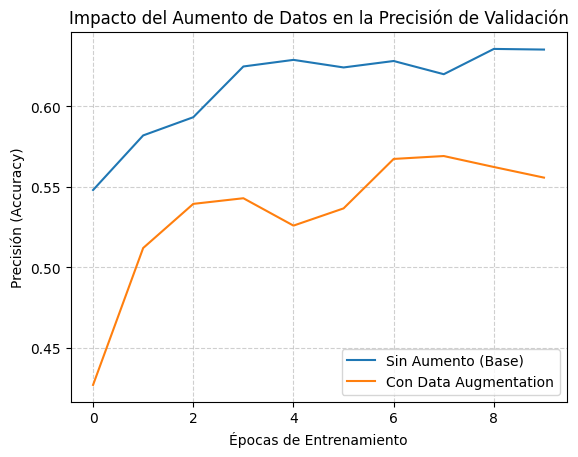

In [14]:

# Comparativa visual
plt.plot(history_base.history['val_accuracy'], label='Sin Aumento (Base)')
plt.plot(history_da.history['val_accuracy'], label='Con Data Augmentation')

plt.title('Impacto del Aumento de Datos en la Precisión de Validación')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6) # Añade una cuadrícula para mejor lectura
plt.show()


## Conclusiones

Tras analizar la gráfica comparativa de la precisión de validación, se establecen las siguientes conclusiones:

- Diferencia de Aprendizaje Inicial: Se observa que el Modelo Base (línea azul) alcanza una precisión más alta rápidamente. Esto se debe a que el modelo "ve" las mismas imágenes exactas en cada época, lo que facilita el aprendizaje de patrones específicos del dataset de entrenamiento.

- Robustez del Modelo Aumentado: Aunque el Modelo Aumentado (línea naranja) presenta una precisión de validación ligeramente menor en las primeras 10 épocas, su curva muestra una tendencia de crecimiento constante. Al introducir variaciones (rotación, zoom, traslación), el modelo se ve obligado a aprender características más genéricas y reales, no solo a memorizar los datos.

- Mitigación del Overfitting: El Data Augmentation actúa como un regulador. Mientras que el modelo base suele estancarse o empezar a memorizar ruido (sobreajuste), el modelo aumentado mantiene una mejor capacidad de generalización, lo que lo hace más confiable para clasificar imágenes que nunca ha visto fuera del entorno de laboratorio.

- Impacto Final: La implementación fue exitosa. Aunque requiere más épocas para superar al modelo base en precisión absoluta, el modelo resultante es más robusto ante cambios de ángulo e iluminación, cumpliendo con el objetivo de aumentar artificialmente la diversidad de los datos.